In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import ipywidgets as widgets
import os
from IPython.display import display, clear_output

%matplotlib inline

Dropdown(description='Select file:', options=('data0932.dat',), value='data0932.dat')

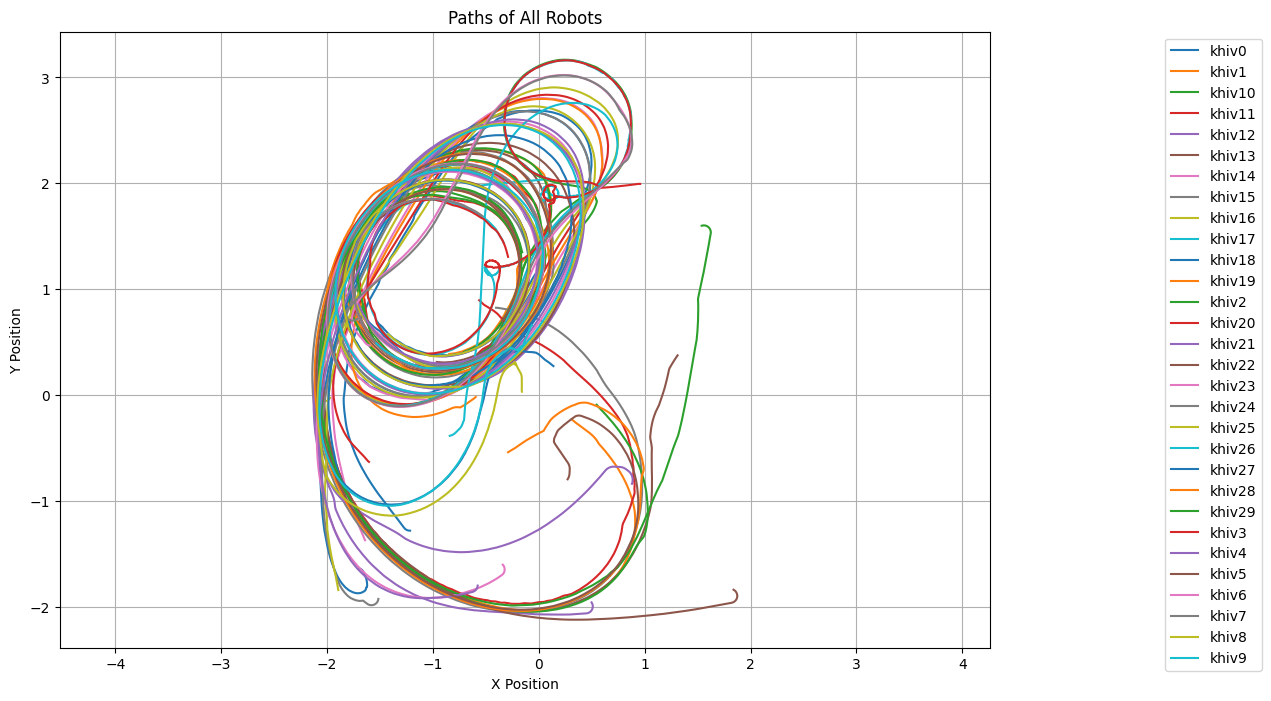

In [2]:

# Load all .dat files in the current directory

# Change directory to ../data before loading files
os.chdir('../data')

# Get list of .dat files
dat_files = [f for f in os.listdir() if f.endswith('.dat')]

# Create dropdown widget for file selection
def load_data(file):
    df = pd.read_csv(file, header=0, names=["timestep", "robot_id", "x", "y", "yaw"])
    return df

file_selector = widgets.Dropdown(
    options=dat_files,
    description='Select file:',
    disabled=False,
)
display(file_selector)
print("Select a file to load data.")

df = load_data(dat_files[-1])

# Update the file_name based on the selection
def on_file_change(change):
    global file_name, df
    file_name = change['new']

    df = load_data(file_name)

file_selector.observe(on_file_change, names='value')


def plot_all_robot_paths():
    clear_output(wait=True)
    display(file_selector)
    plt.figure(figsize=(12, 8))
    df['x'] = df['x'].astype(float)
    df['y'] = df['y'].astype(float)
    df['robot_id'] = df['robot_id'].astype(str)
    for robot in df['robot_id'].unique():
        robot_data = df[df['robot_id'] == robot]
        plt.plot(robot_data['x'], robot_data['y'], label=robot)
    plt.title('Paths of All Robots')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.grid(True)
    plt.axis('equal')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    plt.show()

file_selector.observe(lambda change: plot_all_robot_paths(), names='value')
plot_all_robot_paths()


Dropdown(description='Robot ID:', index=4, options=('khiv0', 'khiv1', 'khiv10', 'khiv11', 'khiv12', 'khiv13', …

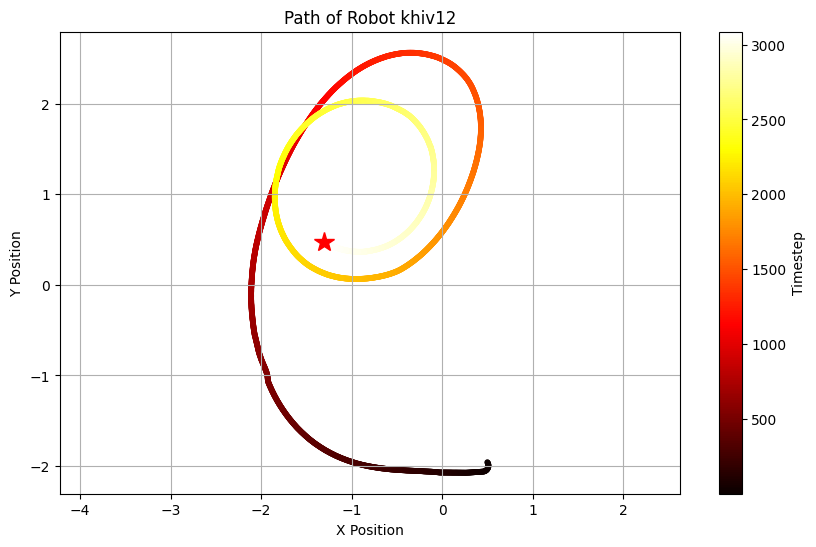

In [13]:
# Create dropdown for robot ID selection
robot_ids = df['robot_id'].unique()
robot_selector = widgets.Dropdown(
    options=robot_ids,
    description='Robot ID:',
    disabled=False,
)
display(robot_selector)

robot_data = None

# Update the robot_id based on the selection
def on_robot_change(change):
    global robot_id
    robot_id = change['new']
robot_selector.observe(on_robot_change, names='value')

def plot_robot_path(change):
    global robot_data
    clear_output(wait=True)
    display(robot_selector)
    plt.figure(figsize=(10, 6))
    robot_data = df[df['robot_id'] == robot_selector.value]
    print(robot_data)
    robot_data['x'] = robot_data['x'].astype(float)
    robot_data['y'] = robot_data['y'].astype(float)
    robot_data['timestep'] = robot_data['timestep'].astype(int)  # Ensure timestep is numeric for coloring
    plt.scatter(robot_data['x'], robot_data['y'], c=robot_data['timestep'], cmap='hot', s=10)
    plt.plot(robot_data['x'].iloc[-1], robot_data['y'].iloc[-1], 'r*', markersize=15, label='Last Point')
    plt.colorbar(label='Timestep')
    plt.title(f'Path of Robot {robot_selector.value}')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

robot_selector.observe(plot_robot_path, names='value')

In [15]:
robot_data

,timestep,robot_id,x,y,yaw
4,1,khiv12,0.497778,-1.957940,-1.00321
34,2,khiv12,0.500130,-1.961630,-1.07152
64,3,khiv12,0.502553,-1.966000,-1.14742
94,4,khiv12,0.504642,-1.970540,-1.22332
124,5,khiv12,0.506379,-1.975230,-1.29922
...,...,...,...,...,...
92434,3082,khiv12,-1.283150,0.465718,2.62244
92464,3083,khiv12,-1.287560,0.468270,2.55982
92494,3084,khiv12,-1.292510,0.471486,2.60347
92524,3085,khiv12,-1.296870,0.474122,2.54085
